# AeroPredict Dataset EDA (NASA C-MAPSS)

This notebook performs exploratory data analysis on the C-MAPSS dataset used in AeroPredict.

## Scope
- Load `train_FD00X`, `test_FD00X`, and `RUL_FD00X` files
- Validate shapes, engines, cycles, and data quality
- Analyze feature distributions and trends
- Build train-side RUL targets for visualization
- Visualize correlations and low-dimensional structure

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
BASE_COLUMNS = ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3']
SENSOR_COLUMNS = [f'sensor_{i}' for i in range(1, 22)]
ALL_COLUMNS = BASE_COLUMNS + SENSOR_COLUMNS

def read_cmapss_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep='\s+', header=None, engine='python')
    df = df.dropna(axis=1, how='all')

    if df.shape[1] != len(ALL_COLUMNS):
        raise ValueError(f'Unexpected column count in {path.name}: {df.shape[1]}')

    df.columns = ALL_COLUMNS
    return df

def build_train_rul(train_df: pd.DataFrame) -> pd.DataFrame:
    max_cycle_per_unit = train_df.groupby('unit_id')['cycle'].max()
    out = train_df.copy()
    out['max_cycle'] = out['unit_id'].map(max_cycle_per_unit)
    out['rul'] = out['max_cycle'] - out['cycle']
    return out

print('Column and helper setup complete')

Column and helper setup complete


In [3]:
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

data_dir = project_root / 'data'
assert data_dir.exists(), f'Data directory not found: {data_dir}'

subsets = ['FD001', 'FD002', 'FD003', 'FD004']

print('Project root:', project_root)
print('Data directory:', data_dir)
print('Available files:')
for p in sorted(data_dir.glob('*.txt')):
    print(' -', p.name)

Project root: c:\Users\kunwa\AI Sem 4\EST PROJECT\AEROPREDICT
Data directory: c:\Users\kunwa\AI Sem 4\EST PROJECT\AEROPREDICT\data
Available files:
 - readme.txt
 - RUL_FD001.txt
 - RUL_FD002.txt
 - RUL_FD003.txt
 - RUL_FD004.txt
 - test_FD001.txt
 - test_FD002.txt
 - test_FD003.txt
 - test_FD004.txt
 - train_FD001.txt
 - train_FD002.txt
 - train_FD003.txt
 - train_FD004.txt


In [4]:
dataset = {}

for ds in subsets:
    train_path = data_dir / f'train_{ds}.txt'
    test_path = data_dir / f'test_{ds}.txt'
    rul_path = data_dir / f'RUL_{ds}.txt'

    train_df = read_cmapss_file(train_path)
    test_df = read_cmapss_file(test_path)
    rul_df = pd.read_csv(rul_path, sep='\s+', header=None, engine='python').dropna(axis=1, how='all')
    rul_df.columns = ['rul']

    dataset[ds] = {
        'train': train_df,
        'test': test_df,
        'rul': rul_df
    }

print('Datasets loaded')
for ds, d in dataset.items():
    print(f"{ds}: train={d['train'].shape}, test={d['test'].shape}, rul={d['rul'].shape}")

Datasets loaded
FD001: train=(20631, 26), test=(13096, 26), rul=(100, 1)
FD002: train=(53759, 26), test=(33991, 26), rul=(259, 1)
FD003: train=(24720, 26), test=(16596, 26), rul=(100, 1)
FD004: train=(61249, 26), test=(41214, 26), rul=(248, 1)


In [5]:
summary_rows = []
for ds, d in dataset.items():
    train_df = d['train']
    test_df = d['test']
    rul_df = d['rul']

    summary_rows.append({
        'dataset': ds,
        'train_rows': len(train_df),
        'test_rows': len(test_df),
        'train_engines': train_df['unit_id'].nunique(),
        'test_engines': test_df['unit_id'].nunique(),
        'train_cycle_min': int(train_df['cycle'].min()),
        'train_cycle_max': int(train_df['cycle'].max()),
        'test_cycle_min': int(test_df['cycle'].min()),
        'test_cycle_max': int(test_df['cycle'].max()),
        'rul_targets': len(rul_df)
    })

summary_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)
summary_df

,dataset,train_rows,test_rows,train_engines,test_engines,train_cycle_min,train_cycle_max,test_cycle_min,test_cycle_max,rul_targets
0,FD001,20631,13096,100,100,1,362,1,303,100
1,FD002,53759,33991,260,259,1,378,1,367,259
2,FD003,24720,16596,100,100,1,525,1,475,100
3,FD004,61249,41214,249,248,1,543,1,486,248


## Focus Dataset for Detailed EDA
Set `focus_ds` to any subset (`FD001`, `FD002`, `FD003`, `FD004`).

In [6]:
focus_ds = 'FD001'
train_df = dataset[focus_ds]['train'].copy()
test_df = dataset[focus_ds]['test'].copy()
rul_df = dataset[focus_ds]['rul'].copy()

train_with_rul = build_train_rul(train_df)

print('Focus dataset:', focus_ds)
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('RUL labels shape:', rul_df.shape)
train_df.head()

Focus dataset: FD001
Train shape: (20631, 26)
Test shape: (13096, 26)
RUL labels shape: (100, 1)


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
quality_df = pd.DataFrame({
    'column': train_df.columns,
    'dtype': [str(train_df[c].dtype) for c in train_df.columns],
    'missing_count': [int(train_df[c].isna().sum()) for c in train_df.columns],
    'missing_pct': [float(train_df[c].isna().mean() * 100) for c in train_df.columns],
    'n_unique': [int(train_df[c].nunique()) for c in train_df.columns]
})

print('Duplicate rows in train:', int(train_df.duplicated().sum()))
quality_df

Duplicate rows in train: 0


,column,dtype,missing_count,missing_pct,n_unique
0,unit_id,int64,0,0.0,100
1,cycle,int64,0,0.0,362
2,setting_1,float64,0,0.0,158
3,setting_2,float64,0,0.0,13
4,setting_3,float64,0,0.0,1
5,sensor_1,float64,0,0.0,1
6,sensor_2,float64,0,0.0,310
7,sensor_3,float64,0,0.0,3012
8,sensor_4,float64,0,0.0,4051
9,sensor_5,float64,0,0.0,1


In [8]:
life_stats = train_df.groupby('unit_id')['cycle'].max().describe().to_frame('train_lifecycle_length')
life_stats

,train_lifecycle_length
count,100.000000
mean,206.310000
std,46.342749
min,128.000000
25%,177.000000
50%,199.000000
75%,229.250000
max,362.000000


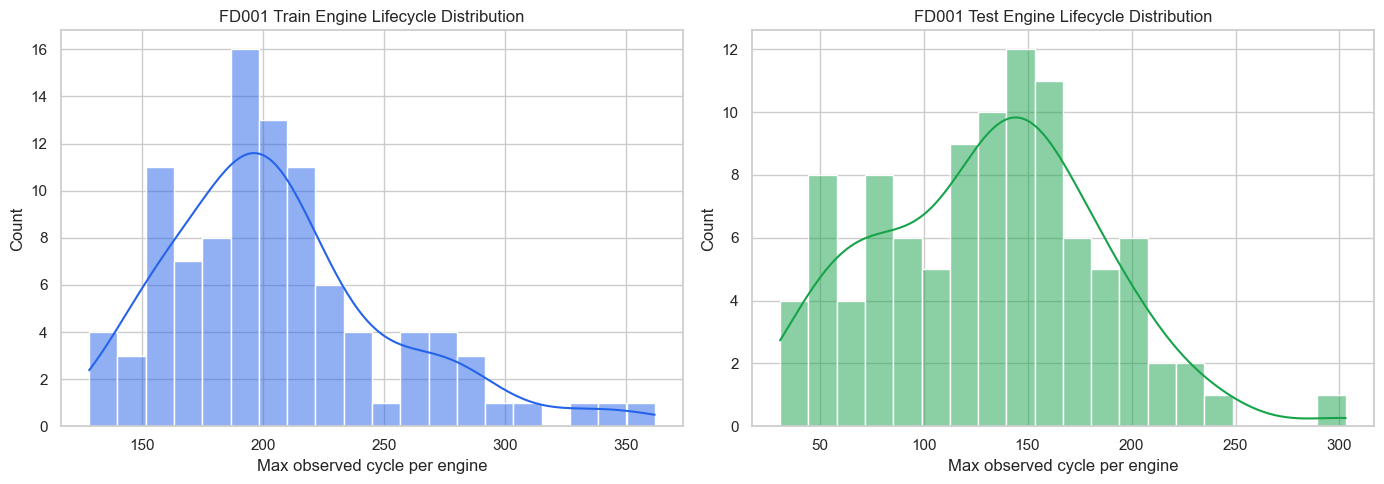

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_life = train_df.groupby('unit_id')['cycle'].max()
test_life = test_df.groupby('unit_id')['cycle'].max()

sns.histplot(train_life, bins=20, kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title(f'{focus_ds} Train Engine Lifecycle Distribution')
axes[0].set_xlabel('Max observed cycle per engine')

sns.histplot(test_life, bins=20, kde=True, ax=axes[1], color='#16a34a')
axes[1].set_title(f'{focus_ds} Test Engine Lifecycle Distribution')
axes[1].set_xlabel('Max observed cycle per engine')

plt.tight_layout()
plt.show()

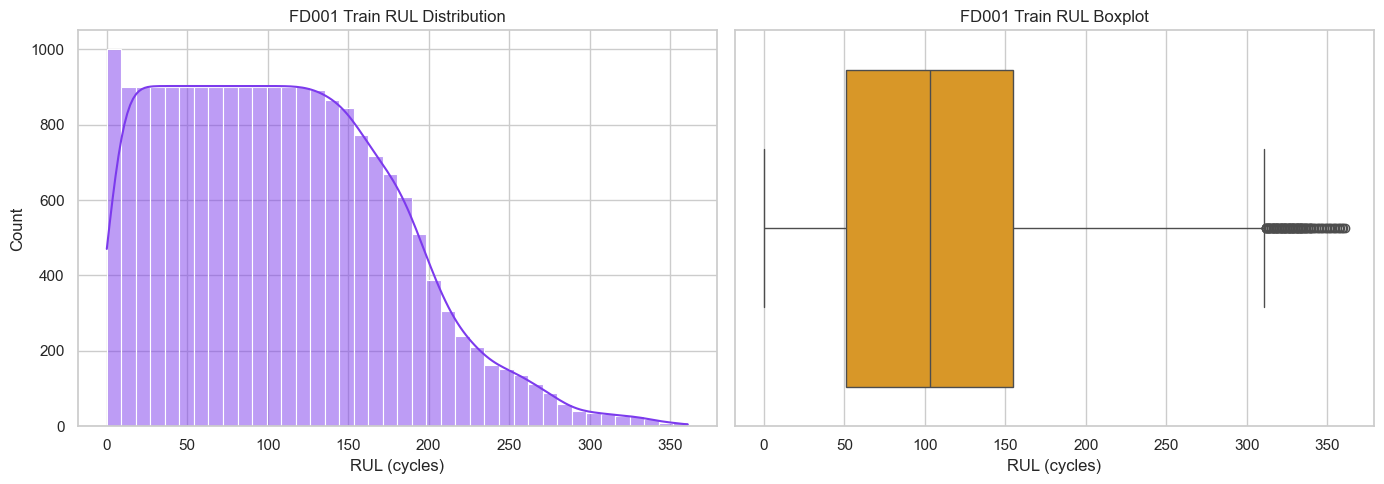

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_with_rul['rul'], bins=40, kde=True, ax=axes[0], color='#7c3aed')
axes[0].set_title(f'{focus_ds} Train RUL Distribution')
axes[0].set_xlabel('RUL (cycles)')

sns.boxplot(x=train_with_rul['rul'], ax=axes[1], color='#f59e0b')
axes[1].set_title(f'{focus_ds} Train RUL Boxplot')
axes[1].set_xlabel('RUL (cycles)')

plt.tight_layout()
plt.show()

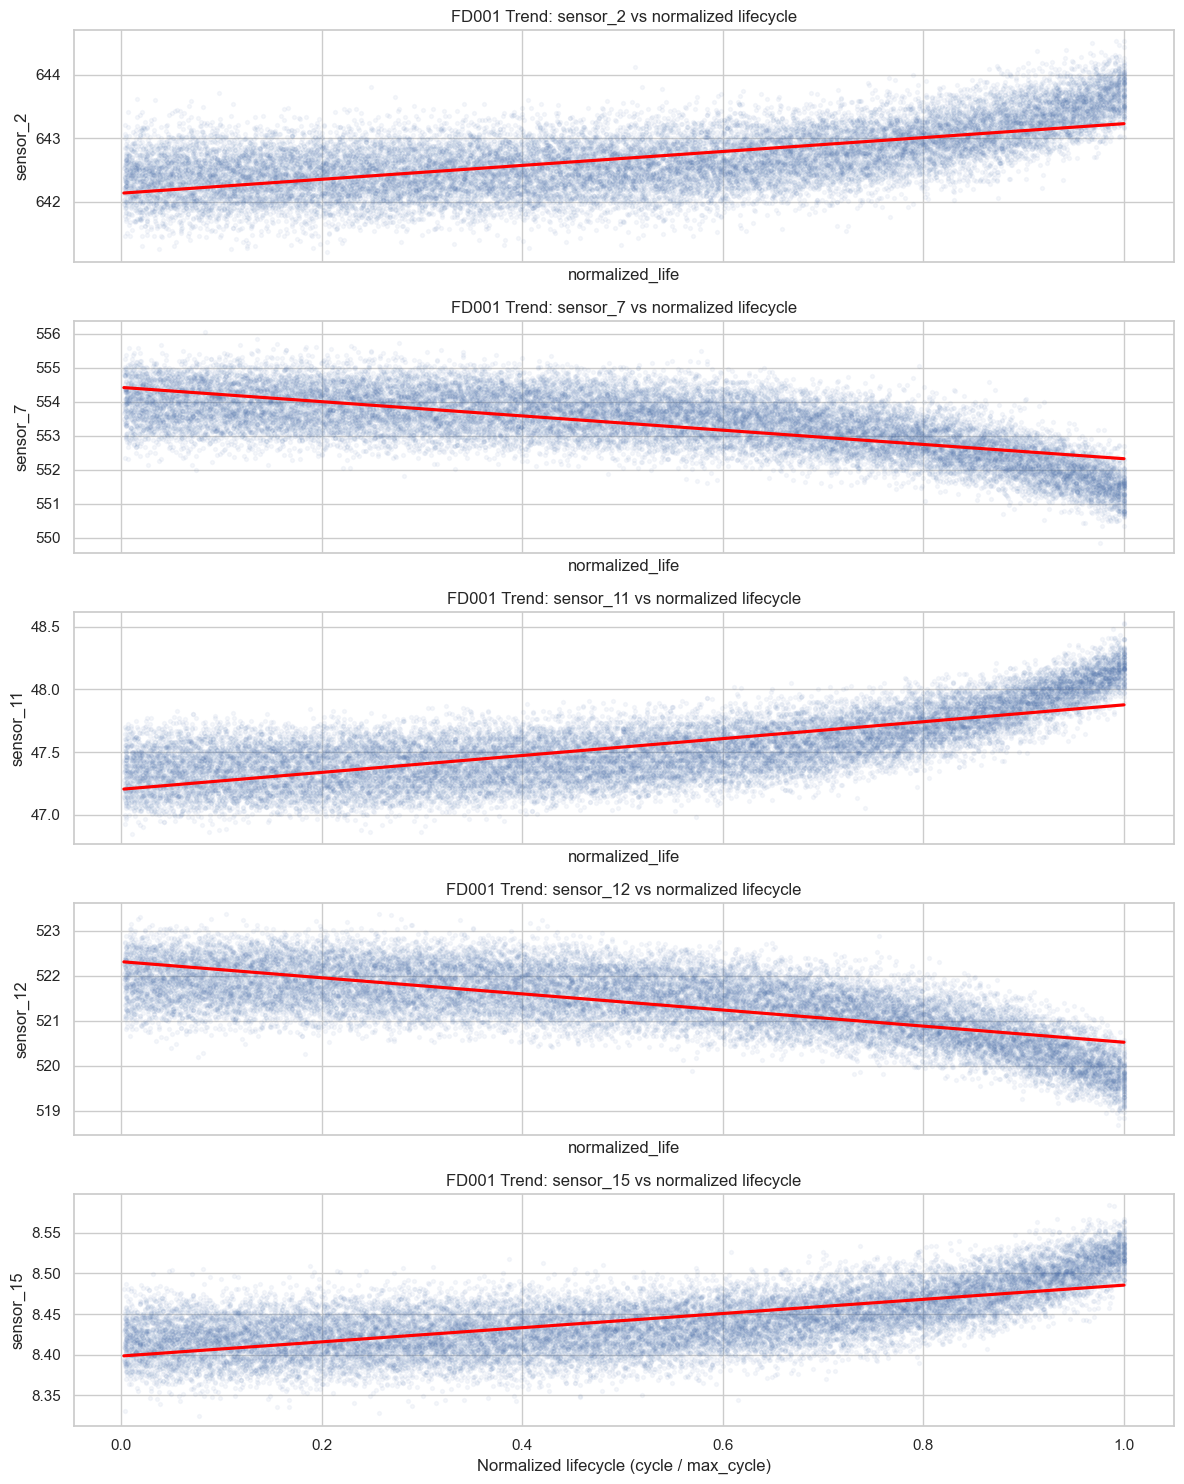

In [11]:
selected_sensors = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_15']

trend_df = train_with_rul.copy()
trend_df['normalized_life'] = trend_df['cycle'] / trend_df['max_cycle']

fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(12, 3 * len(selected_sensors)), sharex=True)

if len(selected_sensors) == 1:
    axes = [axes]

for ax, s in zip(axes, selected_sensors):
    sampled = trend_df[['normalized_life', s]].sample(min(25000, len(trend_df)), random_state=42)
    sns.regplot(data=sampled, x='normalized_life', y=s, scatter_kws={'alpha': 0.05, 's': 8}, line_kws={'color': 'red'}, ax=ax)
    ax.set_title(f'{focus_ds} Trend: {s} vs normalized lifecycle')

axes[-1].set_xlabel('Normalized lifecycle (cycle / max_cycle)')
plt.tight_layout()
plt.show()

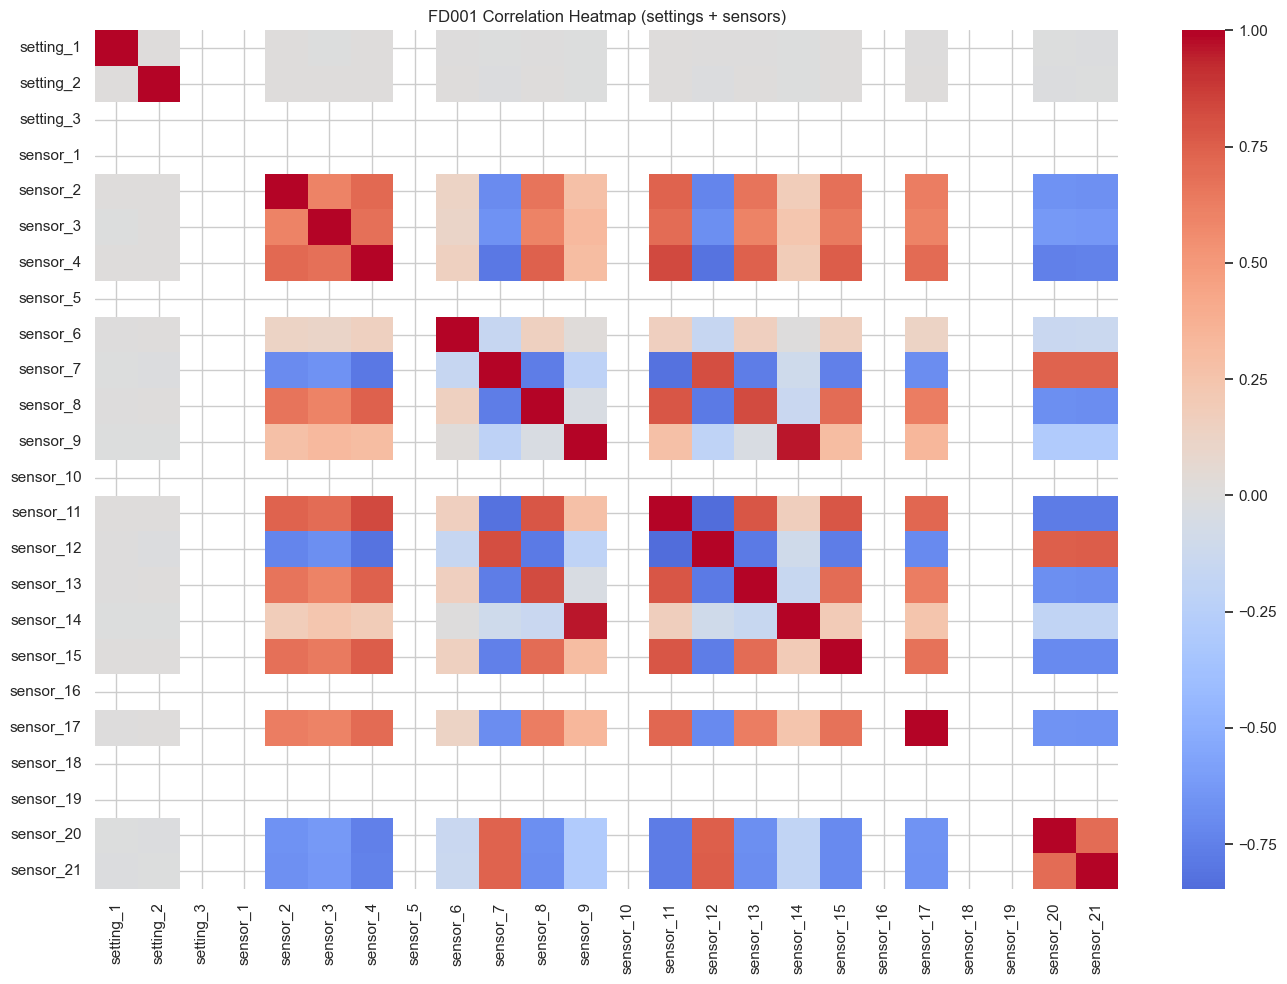

In [12]:
corr_cols = ['setting_1', 'setting_2', 'setting_3'] + SENSOR_COLUMNS
corr_sample = train_df[corr_cols].sample(min(20000, len(train_df)), random_state=42)
corr = corr_sample.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title(f'{focus_ds} Correlation Heatmap (settings + sensors)')
plt.tight_layout()
plt.show()

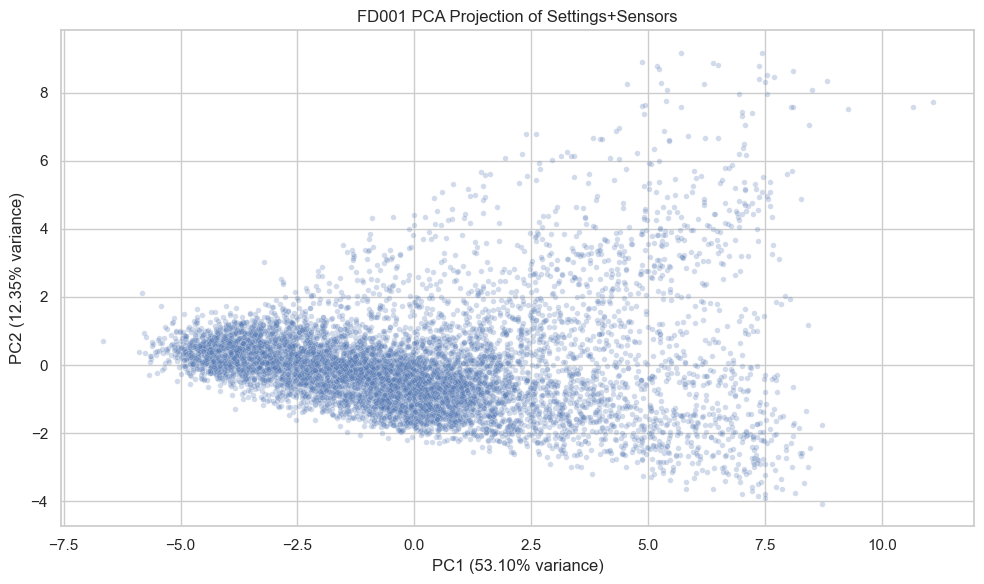

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = ['setting_1', 'setting_2', 'setting_3'] + SENSOR_COLUMNS
pca_df = train_df[pca_features].sample(min(25000, len(train_df)), random_state=42).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1]
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df.sample(min(8000, len(plot_df)), random_state=42), x='PC1', y='PC2', alpha=0.25, s=16)
plt.title(f'{focus_ds} PCA Projection of Settings+Sensors')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)')
plt.tight_layout()
plt.show()

In [14]:
eda_out = project_root / 'data' / f'eda_summary_{focus_ds}.csv'
summary_df.to_csv(eda_out, index=False)
print('Saved dataset-level summary to:', eda_out)
summary_df

Saved dataset-level summary to: c:\Users\kunwa\AI Sem 4\EST PROJECT\AEROPREDICT\data\eda_summary_FD001.csv


,dataset,train_rows,test_rows,train_engines,test_engines,train_cycle_min,train_cycle_max,test_cycle_min,test_cycle_max,rul_targets
0,FD001,20631,13096,100,100,1,362,1,303,100
1,FD002,53759,33991,260,259,1,378,1,367,259
2,FD003,24720,16596,100,100,1,525,1,475,100
3,FD004,61249,41214,249,248,1,543,1,486,248


## EDA Findings Template (Fill After Running)

- Data quality: no/low missingness, duplicate status
- Lifecycle pattern: train vs test cycle length behavior
- RUL shape: skew, spread, outliers
- Sensor drift: sensors that show strong lifecycle trends
- Correlation structure: strongly coupled sensor groups
- Representation: PCA compactness / separability observations

You can now reuse this notebook for each FD subset by changing `focus_ds`.